In [1]:
from typing import List, NamedTuple, Union, Callable, Tuple
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
import random
import itertools
import tqdm
import math

In [2]:
Vector = List[float]

def argmax(v: list) -> int:
    """Devuelve el índice del valor máximo en la lista v"""
    return v.index(max(v))

# Primero necesitamos poder sumar una lista de vectores
def vector_sum(vectors: List[Vector]) -> Vector:
    """Suma todos los vectores correspondientes"""
    num_elements = len(vectors[0])
    return [sum(v[i] for v in vectors)
            for i in range(num_elements)]

# Ahora definimos el promedio
def vector_mean(vectors: List[Vector]) -> Vector:
    """Calcula el vector cuyo i-ésimo elemento es la media de los
    i-ésimos elementos de los vectores de entrada."""
    n = len(vectors)
    return [x / n for x in vector_sum(vectors)]

def vector_subtract(v: Vector, w: Vector) -> Vector:
    """Resta elementos correspondientes: [v1 - w1, v2 - w2, ...]"""
    return [v_i - w_i for v_i, w_i in zip(v, w)]

def sum_of_squares(v: Vector) -> float:
    """Devuelve v_1 * v_1 + ... + v_n * v_n"""
    return sum(v_i ** 2 for v_i in v)

def squared_distance(v: Vector, w: Vector) -> float:
    """Calcula (v_1 - w_1)**2 + ... + (v_n - w_n)**2"""
    return sum_of_squares(vector_subtract(v, w))

# Creamos puntos alrededor de tres centros específicos
inputs = (
    [[ -26 + random.random(),  -5 + random.random()] for _ in range(30)] +
    [[  18 + random.random(),  20 + random.random()] for _ in range(30)]
)

def distance(v1: Vector, v2: Vector) -> float:
    """Calcula la distancia euclidiana entre v1 y v2"""
    return math.sqrt(squared_distance(v1, v2))

In [3]:
def num_differences(v1: Vector, v2: Vector) -> int:
    assert len(v1) == len(v2)
    return len([x1 for x1, x2 in zip(v1, v2) if x1 != x2])

assert num_differences([1, 2, 3], [2, 1, 3]) == 2
assert num_differences([1, 2], [1, 2]) == 0

In [4]:
def cluster_means(k: int, inputs: List[Vector], assignment: List[int]) -> List[Vector]:
    # clusters[i] contiene las entradas cuya asignasion es i
    clusters = [[] for i in range(k)]
    for input, assignment in zip(inputs, assignment):
        clusters[assignment].append(input)
    # si un grupo esta vacio, usa un punto aleatorio
    return [vector_mean(cluster) if cluster else random.choice(inputs) for cluster in clusters]

In [5]:
class KMeans:
    def __init__(self, k: int) -> None:
        self.k = k
        self.means = None
    
    def classify(self, input: Vector) -> int:
        """Devolver el índice del clúster más cercano a la entrada"""
        return min(range(self.k), key=lambda i: squared_distance(input, self.means[i]))
    
    def train(self, inputs: List[Vector]) -> None:
        # inicia con asignaciones aleatorias
        assignments = [random.randrange(self.k) for _ in inputs]
        with tqdm.tqdm(itertools.count()) as t:
            for _ in t:
                # calcula la media y halla nuevas asignaciones
                self.means = cluster_means(self.k, inputs, assignments)
                new_assignments = [self.classify(input) for input in inputs]
                # conprueba cuantas asignaciones cambiaron y si hemos terminado
                num_chaged = num_differences(assignments, new_assignments)
                if num_chaged == 0:
                    return
                # si no mantiene las nuevas asignaciones y calcula nuevas medias
                assignments = new_assignments
                self.means = cluster_means(self.k, inputs, assignments)
                t.set_description(f"changed: {num_chaged} / {len(inputs)}")

# Encuentros

In [6]:
random.seed(12)
clusterer = KMeans(k=3)
clusterer.train(inputs)
means = sorted(clusterer.means)
assert len(means) == 3

# revisa que las medidas esten cerca de lo que esperamos
#assert squared_distance(means[0], [-44, 5]) < 1
#assert squared_distance(means[1], [-16, -10]) < 1
#assert squared_distance(means[2], [18, 20]) < 1

changed: 1 / 60: : 4it [00:00, 640.38it/s]


In [7]:
random.seed(0)
clusterer = KMeans(k=2)
clusterer.train(inputs)
means = sorted(clusterer.means)

assert len(means) == 2
assert squared_distance(means[0], [-26, -5]) < 1
assert squared_distance(means[1], [18, 20]) < 1

changed: 25 / 60: : 1it [00:00, 238.06it/s]


In [8]:
def squared_clustering_errors(inputs: List[Vector], k: int) -> float:
    """Encuentra el error cuadrado total de k-means agrupando las entradas"""
    clusterer = KMeans(k)
    clusterer.train(inputs)
    means = clusterer.means
    assignments = [clusterer.classify(input) for input in inputs]
    return sum(squared_distance(input, means[cluster]) for input, cluster in zip(inputs, assignments))

0it [00:00, ?it/s]
changed: 26 / 60: : 1it [00:00, 587.36it/s]
changed: 1 / 60: : 4it [00:00, 673.49it/s]
changed: 4 / 60: : 4it [00:00, 739.44it/s]
changed: 1 / 60: : 6it [00:00, 544.70it/s]
changed: 1 / 60: : 5it [00:00, 319.30it/s]
changed: 1 / 60: : 8it [00:00, 374.01it/s]
changed: 2 / 60: : 4it [00:00, 363.21it/s]
changed: 1 / 60: : 7it [00:00, 322.57it/s]
changed: 3 / 60: : 4it [00:00, 327.39it/s]
changed: 1 / 60: : 7it [00:00, 422.82it/s]
changed: 1 / 60: : 5it [00:00, 431.70it/s]
changed: 3 / 60: : 4it [00:00, 411.85it/s]
changed: 2 / 60: : 4it [00:00, 337.96it/s]
changed: 1 / 60: : 4it [00:00, 269.97it/s]
changed: 1 / 60: : 4it [00:00, 290.93it/s]
changed: 2 / 60: : 4it [00:00, 267.32it/s]
changed: 3 / 60: : 4it [00:00, 203.56it/s]
changed: 2 / 60: : 5it [00:00, 204.08it/s]
changed: 5 / 60: : 3it [00:00, 155.62it/s]
changed: 2 / 60: : 4it [00:00, 187.10it/s]
changed: 3 / 60: : 4it [00:00, 201.14it/s]
changed: 6 / 60: : 3it [00:00, 236.67it/s]
changed: 10 / 60: : 3it [00:00, 13

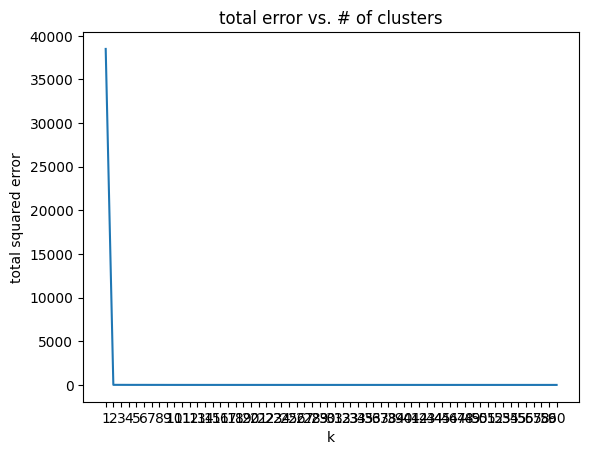

In [9]:
# ahora traza desde 1 hasta len(inputs) clusteres

ks = range(1, len(inputs) + 1)
errors = [squared_clustering_errors(inputs, k) for k in ks]

plt.plot(ks, errors)
plt.xticks(ks)
plt.xlabel("k")
plt.ylabel("total squared error")
plt.title("total error vs. # of clusters")
plt.show()

# agrupando colores

In [10]:
image_path = r"bird-colorful-logo-gradient-vector_343694-1365.jpg"
img = mpimg.imread(image_path) / 256

In [11]:
top_row = img[0]
top_left_pixel = top_row[0]
red, grees, blue = top_left_pixel

In [12]:
# .tolist() convierte un array NumPy en una lista Python
pixels = [pixel.tolist() for row in img for pixel in row]

In [13]:
clusterer = KMeans(5)
clusterer.train(pixels)

changed: 1 / 547600: : 25it [01:52,  4.52s/it]    


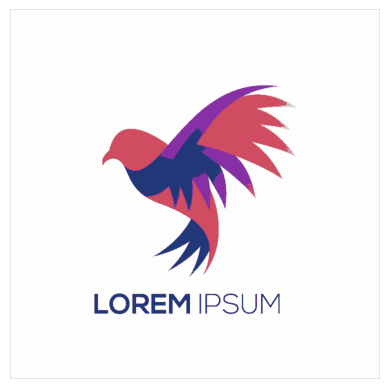

In [14]:
def recolor(pixel: Vector) -> Vector:
    cluster = clusterer.classify(pixel)
    return clusterer.means[cluster]
new_img = [[recolor(pixel) for pixel in row] for row in img]

plt.imshow(new_img)
plt.axis('off')
plt.show()

In [15]:
class Leaf(NamedTuple):
    value: Vector

leaf1 = Leaf([10, 20])
leaf2 = Leaf([30, -15])

In [16]:
class Merged(NamedTuple):
    children: tuple
    order: int

merged = Merged((leaf1, leaf2), order=1)
Cluster = Union[Leaf, Merged]

In [17]:
def get_values(cluster: Cluster) -> List[Vector]:
    if isinstance(cluster, Leaf):
        return [cluster.value]
    else:
        return [value for child in cluster.children for value in get_values(child)]
    
assert get_values(merged) == [[10, 20], [30, -15]]

In [18]:
def cluster_distance(cluster1: Cluster, cluster2: Cluster, distance_agg: Callable = min) -> float:
    # Extraemos los puntos una vez para no repetir la recursión
    values1 = get_values(cluster1)
    values2 = get_values(cluster2)
    
    return distance_agg([distance(v1, v2) for v1 in values1 for v2 in values2])

In [19]:
def get_merge_order(cluster: Cluster) -> float:
    if isinstance(cluster, Leaf):
        return float('inf')
    else:
        return cluster.order

In [20]:
def get_children(cluster: Cluster):
    if isinstance(cluster, Leaf):
        raise TypeError("leaf has no children")
    else:
        return cluster.children

In [21]:
def bottom_up_cluster(inputs: List[Vector], distance_agg: Callable = min) -> Cluster:
    # empieza con todas las hojas
    clusters: List[Cluster] = [Leaf(input) for input in inputs]

    def pair_distance(pair: Tuple[Cluster, Cluster]) -> float:
        return cluster_distance(pair[0], pair[1], distance_agg)
    # siempre que quede mas de un cluster
    while len(clusters) > 1:
        # halla los dos grupos mas cercanos
        c1, c2 = min(((cluster1, cluster2) for i, cluster1 in enumerate(clusters) for cluster2 in clusters[:i]), key=pair_distance)
        #los quita de la lista de clusters
        clusters = [c for c in clusters if c != c1 and c != c2]\
        # los combina, usando merge_order = nº de clusteres que quedan
        merged_cluster = Merged((c1, c2), order=len(clusters))
        # y aniade su combinacion
        clusters.append(merged_cluster)
    # cuado solo queda un cluster, lo devuelve
    return clusters[0]

In [22]:
base_cluster = bottom_up_cluster(inputs)

In [23]:
def generate_clusters(base_cluster: Cluster, num_clusters: int) -> List[Cluster]:
    # empieza con una lista con solo el grupo base
    clusters = [base_cluster]
    # siempre que no tengamos aun suficientes grupo ...
    while len(clusters) < num_clusters:
        # elige el ultimo combinado de nuestros grupos
        next_cluster = min(clusters, key=get_merge_order)
        # lo queta de la lista
        clusters = [ c for c in clusters if c != next_cluster]
        # y aniade sus hijos a la lista (esdecir, los descombina)
        clusters.extend(get_children(next_cluster))
    # cuando tenemos suficientes clusters...
    return clusters

In [24]:
three_clusters = [get_values(cluster) for cluster in generate_clusters(base_cluster, 3)]

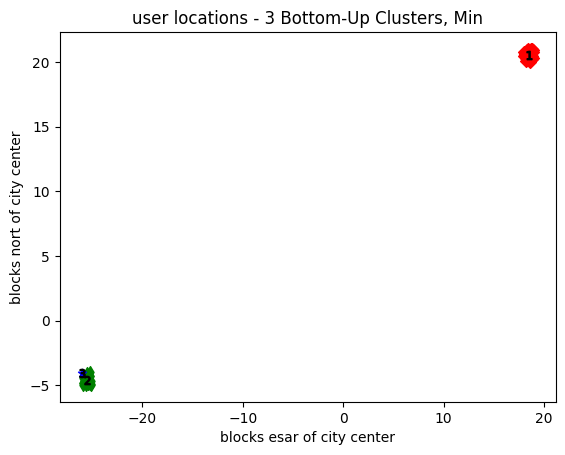

In [25]:
for i, cluster, marker, color in zip([1, 2, 3], three_clusters, ['D', 'd', '*'], ['r', 'g', 'b']):
    xs, ys = zip(*cluster)
    plt.scatter(xs, ys, color=color, marker=marker)
    # pone un numero en la media del cluster
    x, y = vector_mean(cluster)
    plt.plot(x, y, marker='$' + str(i) + '$', color='black')

plt.title("user locations - 3 Bottom-Up Clusters, Min")
plt.xlabel("blocks esar of city center")
plt.ylabel("blocks nort of city center")
plt.show()